In [140]:
"""
PROJECT TITLE: Oxymove (MOXY)
--------------------------------------------------
DESCRIPTION:
    This script aims to process raw torque data collected from the Biodex System 3 isokinetic dynamometer 
    during a concentric and eccentric task. The script will extract relevant metrics such as peak torque, time to peak torque, and total work done.
    The scipts plots the torque curves through time with some addons such as the mean, standard deviation skewness, kurtosis and events.

AUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)
CONTACT: yann.devaux@etu.umontpellier.fr
CREATED: 03/03/2026
VERSION: 0.0.1

INPUTS:
    - Compressed raw torque data (.tsv.gz)
    - Event markers file (.tsv)
    - Configuration file (.json)

OUTPUTS:
    - various plots and measures

LIBRARIES:
    Numpy, Pandas, Matplotlib, Shutil, Scipy, Gzip, Glob, Os, Json
"""

'\nPROJECT TITLE: Oxymove (MOXY)\n--------------------------------------------------\nDESCRIPTION:\n    This script aims to process raw torque data collected from the Biodex System 3 isokinetic dynamometer \n    during a concentric and eccentric task. The script will extract relevant metrics such as peak torque, time to peak torque, and total work done.\n    The scipts plots the torque curves through time with some addons such as the mean, standard deviation skewness, kurtosis and events.\n\nAUTHOR: Devaux Yann (EuroMov DHM / University of Montpellier)\nCONTACT: yann.devaux@etu.umontpellier.fr\nCREATED: 03/03/2026\nVERSION: 0.0.1\n\nINPUTS:\n    - Compressed raw torque data (.tsv.gz)\n    - Event markers file (.tsv)\n    - Configuration file (.json)\n\nOUTPUTS:\n    - various plots and measures\n\nLIBRARIES:\n    Numpy, Pandas, Matplotlib, Shutil, Scipy, Gzip, Glob, Os, Json\n'

## To make sure you have all the required libraries installed, you can run the following command in your terminal: 

In [141]:
#pip install gzip shutil pandas matplotlib numpy json scipy glob 

## Importing libraries

In [142]:
import gzip
import importlib
import json
import os
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure the notebook can import the local helper module from main_scritps
module_dir = os.path.dirname(os.path.abspath('torque_functions_oxymove.py'))
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)

import torque_functions_oxymove as TORQUE_oxymove
TORQUE_oxymove = importlib.reload(TORQUE_oxymove)

assert hasattr(TORQUE_oxymove, 'compute_and_plot_basic_torque_stats'), (
    'compute_and_plot_basic_torque_stats not found in torque_functions_oxymove.py'
    )

## Choosing which subject (**001**-**023**), which session (**001** or **002**), and what modality of contraction (**concentric** or **eccentric**)

In [143]:
subID = '001'
sesID = '001'
BASE_ROOT = r"C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids"

modality = TORQUE_oxymove.infer_task_from_session(
    subject_id=subID,
    session_id=sesID,
    base_root=BASE_ROOT,
    task_choice=None,
    )

base_beh = os.path.join(
    BASE_ROOT,
    f'sub-{subID}',
    f'ses-{sesID}',
    'beh',
    f'sub-{subID}_ses-{sesID}_task-{modality}',
)

torque_file_path = f'{base_beh}_recording-torque_physio.tsv.gz'
frequency_file_path = f'{base_beh}_recording-torque_physio.json'
events_filepath = f'{base_beh}_events.tsv'

print(f'Selected task for ses-{sesID}: {modality}')
print(f'Torque file: {torque_file_path}')

Selected task for ses-001: concentric
Torque file: C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\data\MOXY-bids\sub-001\ses-001\beh\sub-001_ses-001_task-concentric_recording-torque_physio.tsv.gz


## Extract the .gz file

In [144]:
with gzip.open(torque_file_path, 'rb') as f_in:
    with open('file', 'wb') as f_out:
       shutil.copyfileobj(f_in, f_out)

## Load a TSV file

In [145]:
df = pd.read_csv(torque_file_path, sep='\t', header=None, names=['torque_Nm'])
#display the first few rows of the dataframe to check if it loaded correctly
print(df.head())
print(df.columns)

   torque_Nm
0  -0.049765
1   0.430278
2   0.526286
3   0.814312
4   0.526286
Index(['torque_Nm'], dtype='str')


## Load a JSON file to extract the sampling frequency

In [146]:
frequency_file_path = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_recording-torque_physio.json"""
with open(frequency_file_path, 'r') as f:
    frequency_data = json.load(f)
sampling_frequency = frequency_data['SamplingFrequency']
fs=sampling_frequency

## Add the events marker to the torque file

In [147]:
events_filepath = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_events.tsv"""
events = pd.read_csv(events_filepath, sep="\t")
print(events)

#Add a time column to the dataframe
df["time"] = np.arange(len(df))/fs

          onset  duration       trial_type
0    105.639500         0  occlusion_start
1    405.737147         0   occlusion_stop
2    918.723293         0              MVC
3    992.726686         0              MVC
4   1066.132068         0              MVC
5   1260.835733         0            Con50
6   1389.520155         0            Con50
7   1519.444601         0            Con50
8   1732.394609         0            Con30
9   1862.235053         0            Con30
10  1991.915494         0            Con30
11  2206.353531         0              MVC


## This cell gives a first visual of the data

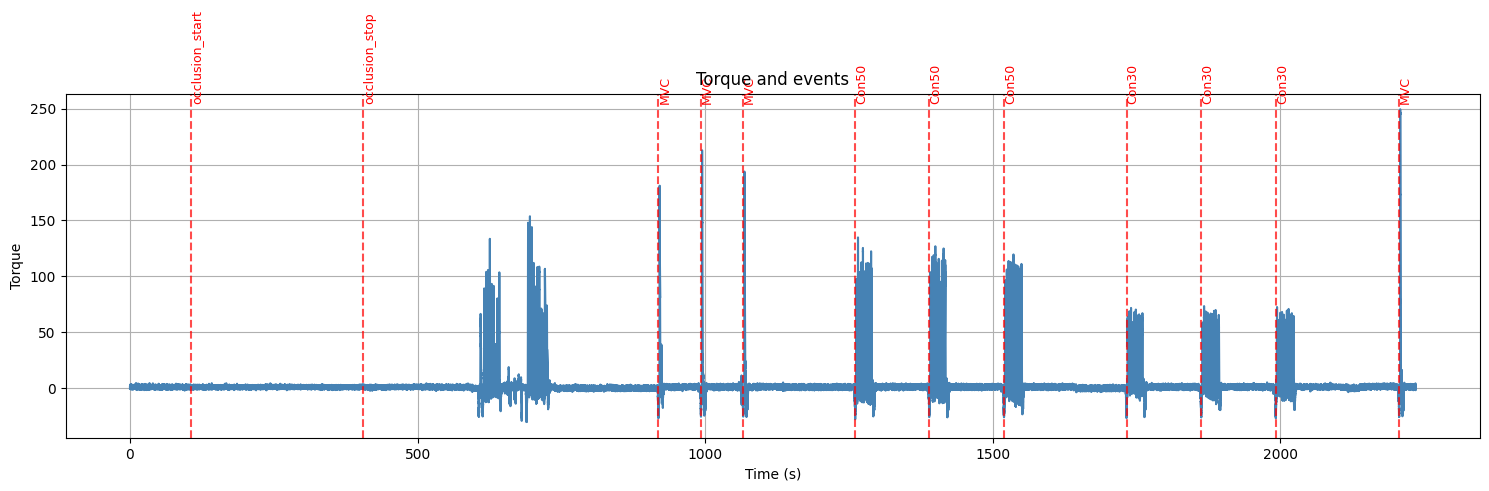

In [148]:
plt.figure(figsize=(15, 5))

#torque
plt.plot(df["time"], df["torque_Nm"], label="Torque", color="steelblue")

#automatical vertical lines for each event
for onset, label in zip(events["onset"], events["trial_type"]):
    plt.axvline(onset, color="red", linestyle="--", alpha=0.7)
    plt.text(onset, df["torque_Nm"].max()*1.02, label, rotation=90,
             verticalalignment="bottom", fontsize=9, color="red")

plt.xlabel("Time (s)")
plt.ylabel("Torque")
plt.title("Torque and events")
plt.grid(True)
plt.tight_layout()
plt.show()

## Computing basic statistics

Mean Torque: 3.460985687269715 Nm
Standard Deviation of Torque: 16.318759060519778 Nm
Skewness of Torque: 5.532165591180922
Kurtosis of Torque: 38.3847428505714


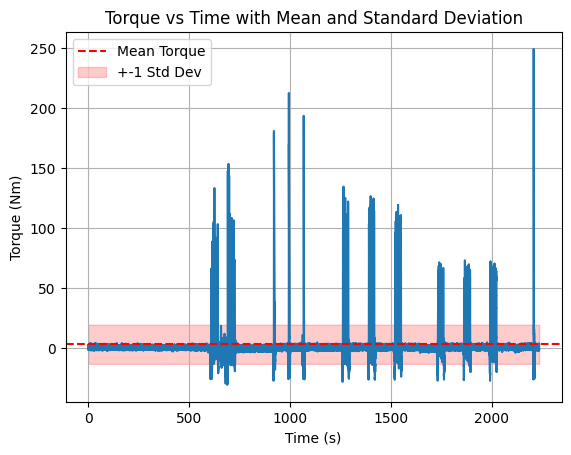

In [149]:
torque_stats = TORQUE_oxymove.compute_and_plot_basic_torque_stats(df)
mean_torque = torque_stats['mean_torque']
std_torque = torque_stats['std_torque']
skewness_torque = torque_stats['skewness_torque']
kurtosis_torque = torque_stats['kurtosis_torque']

## This cell checks MVC quality with the following rule:
## Take the best MVC among the first 3 trials, build a +/-15% acceptance range, and accept the subject if the last MVC is within this range.

In [150]:
mvc_stats = TORQUE_oxymove.compute_mvc_quality_stats(
    df_source=df,
    events_source=events,
    mvc_window=6,
    reference_values=None,
    tolerance_pct=0.15,
    )

# Keep legacy variable names for downstream cells
mvc_events = mvc_stats['mvc_events']
mvc_max_values = mvc_stats['mvc_max_values']
average_mvc_max = mvc_stats['average_mvc_max']
group_A = mvc_stats['group_A']
last = mvc_stats['last']
t_stat = mvc_stats['t_stat']
p_value = mvc_stats['p_value']

# New exclusion method: best of first 3 MVCs +/-15%
best_mvc_first3 = mvc_stats['best_mvc_first3']
lower_bound = mvc_stats['lower_bound']
upper_bound = mvc_stats['upper_bound']
subject_is_eligible = mvc_stats['is_subject_eligible']
subject_status = 'OK' if subject_is_eligible else 'NOT OK'

print(
    f"sub-{subID} | ses-{sesID} | task={modality} | status: {subject_status} | "
    f"best_first3={best_mvc_first3:.3f} Nm | last={last:.3f} Nm | "
    f"range=[{lower_bound:.3f}, {upper_bound:.3f}] Nm (tol={mvc_stats['tolerance_pct']*100:.1f}%)"
 )
if not subject_is_eligible:
    print(f"Reason: {mvc_stats['exclusion_reason']}")

# Summary for all subjects and all sessions (task auto-detected per session)
mvc_eligibility_summary = TORQUE_oxymove.summarize_mvc_eligibility_all_sessions(
    base_root=BASE_ROOT,
    mvc_window=6,
    tolerance_pct=0.15,
    print_summary=True,
    )
mvc_eligibility_summary

Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
Best MVC among reference trials: 212.705 Nm
Acceptance range (+/- 15.0%): [180.800, 244.611] Nm
Last MVC: 249.429 Nm
MVC quality check FAILED. Subject should be excluded from analysis.
sub-001 | ses-001 | task=concentric | status: NOT OK | best_first3=212.705 Nm | last=249.429 Nm | range=[180.800, 244.611] Nm (tol=15.0%)
Reason: MVC quality check FAILED: last MVC is outside +/- tolerance around best reference MVC.
Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
Best MVC among reference trials: 212.705 Nm
Acceptance range (+/- 15.0%): [180.800, 244.611] Nm
Last MVC: 249.429 Nm
MVC quality check FAILED. Subject should be excluded from analysis.
Max torque for each MVC: [320.09274, 379.47406, 356.336, 367.76102]
Average Max Torque across the 3 first MVCs: 351.9676 Nm
Best 

,Subject,Session,Task,Status,n_MVC,Best_MVC_First3_Nm,Last_MVC_Nm,Lower_Bound_Nm,Upper_Bound_Nm,Tolerance_pct,p_value,alpha,Average_MVC_Nm,Reason
0,001,001,concentric,NOT_OK,4.0,212.705340,249.428630,180.799539,244.611141,15.0,NaN,0.05,195.823823,MVC quality check FAILED: last MVC is outside ...
1,001,002,eccentric,OK,4.0,379.474060,367.761020,322.552951,436.395169,15.0,NaN,0.05,351.967600,
2,002,001,eccentric,OK,4.0,332.624270,296.993070,282.730630,382.517910,15.0,NaN,0.05,320.653597,
3,002,002,concentric,OK,4.0,195.610370,192.586090,166.268814,224.951925,15.0,NaN,0.05,192.634100,
4,003,001,eccentric,OK,3.0,219.514110,240.972030,186.586993,252.441226,15.0,NaN,0.05,210.441293,
5,003,002,concentric,OK,4.0,142.834430,132.705520,121.409265,164.259594,15.0,NaN,0.05,141.218283,
6,004,001,concentric,NOT_OK,4.0,216.643450,180.064160,184.146932,249.139967,15.0,NaN,0.05,203.570280,MVC quality check FAILED: last MVC is outside ...
7,004,002,eccentric,OK,4.0,269.350430,261.765750,228.947866,309.752994,15.0,NaN,0.05,267.670277,
8,005,001,concentric,OK,4.0,154.945900,162.612200,131.704015,178.187785,15.0,NaN,0.05,147.364427,
9,005,002,eccentric,OK,4.0,305.890660,264.750980,260.007061,351.774259,15.0,NaN,0.05,294.724060,


## Paired t-test across subjects: PRE vs POST MVC
This cell compares PRE MVC (best reference MVC) vs POST MVC (last MVC) over all subjects and displays a paired pre-post plot.

Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
Best MVC among reference trials: 212.705 Nm
Acceptance range (+/- 15.0%): [180.800, 244.611] Nm
Last MVC: 249.429 Nm
MVC quality check FAILED. Subject should be excluded from analysis.
Max torque for each MVC: [320.09274, 379.47406, 356.336, 367.76102]
Average Max Torque across the 3 first MVCs: 351.9676 Nm
Best MVC among reference trials: 379.474 Nm
Acceptance range (+/- 15.0%): [322.553, 436.395] Nm
Last MVC: 367.761 Nm
MVC quality check PASSED. Subject can be used.
Max torque for each MVC: [306.94196, 332.62427, 322.39456, 296.99307]
Average Max Torque across the 3 first MVCs: 320.6535966666667 Nm
Best MVC among reference trials: 332.624 Nm
Acceptance range (+/- 15.0%): [282.731, 382.518] Nm
Last MVC: 296.993 Nm
MVC quality check PASSED. Subject can be used.
Max torque for each MVC: [190.90594, 195.61037, 191.38599, 192.58609]
Average Max Torque acros

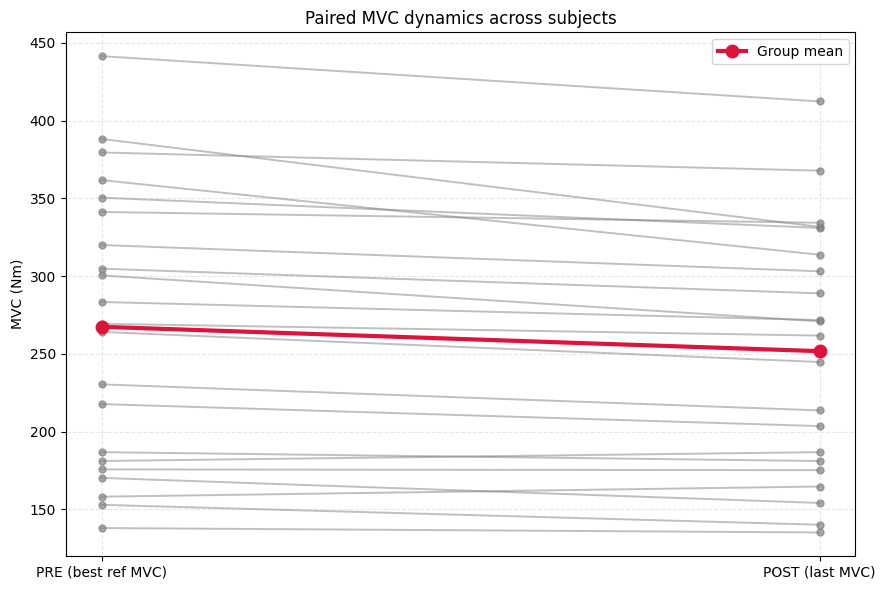

,Subject,Pre_MVC_Nm,Post_MVC_Nm,n_pairs
0,001,379.474060,367.761020,1
1,002,264.117320,244.789580,2
2,003,181.174270,186.838775,2
3,004,269.350430,261.765750,1
4,005,230.418280,213.681590,2
5,006,152.987655,140.200505,2
6,007,441.380435,412.297030,2
7,009,304.762900,288.921475,2
8,010,350.417065,330.971725,2
9,012,341.231430,334.287610,2


In [151]:
paired_test = TORQUE_oxymove.paired_ttest_mvc_pre_post(
    base_root=BASE_ROOT,
    mvc_window=6,
    tolerance_pct=0.15,
    include_only_eligible=True,
    aggregate_by_subject=True,
    make_plot=True,
    print_stats=True,
    )

paired_test['used_pairs_df']

In [152]:
# External torque utilities are now in main_scritps/torque_functions_oxymove.py
window = 30
peak_min_interval = 2.6
print('Torque helper functions loaded from torque_functions_oxymove.py')

Torque helper functions loaded from torque_functions_oxymove.py


## This cell shows the evolution of the deployed force between 2 intensities (30% of MVC and 50% of MVC), for both eccentric and concentric tasks.


PROCESSING CONCENTRIC DATA
Con30 set 1: 10 peaks detected, mean = 66.211 Nm
Con30 set 2: 10 peaks detected, mean = 66.321 Nm
Con30 set 3: 10 peaks detected, mean = 66.854 Nm
Con50 set 1: 10 peaks detected, mean = 112.592 Nm
Con50 set 2: 10 peaks detected, mean = 114.200 Nm
Con50 set 3: 10 peaks detected, mean = 109.352 Nm

PROCESSING ECCENTRIC DATA
Ecc30 set 1: 8 peaks detected, mean = 126.443 Nm
Ecc30 set 2: 10 peaks detected, mean = 121.374 Nm
Ecc30 set 3: 10 peaks detected, mean = 113.809 Nm
Ecc50 set 1: 10 peaks detected, mean = 203.505 Nm
Ecc50 set 2: 9 peaks detected, mean = 199.543 Nm
Ecc50 set 3: 10 peaks detected, mean = 188.196 Nm


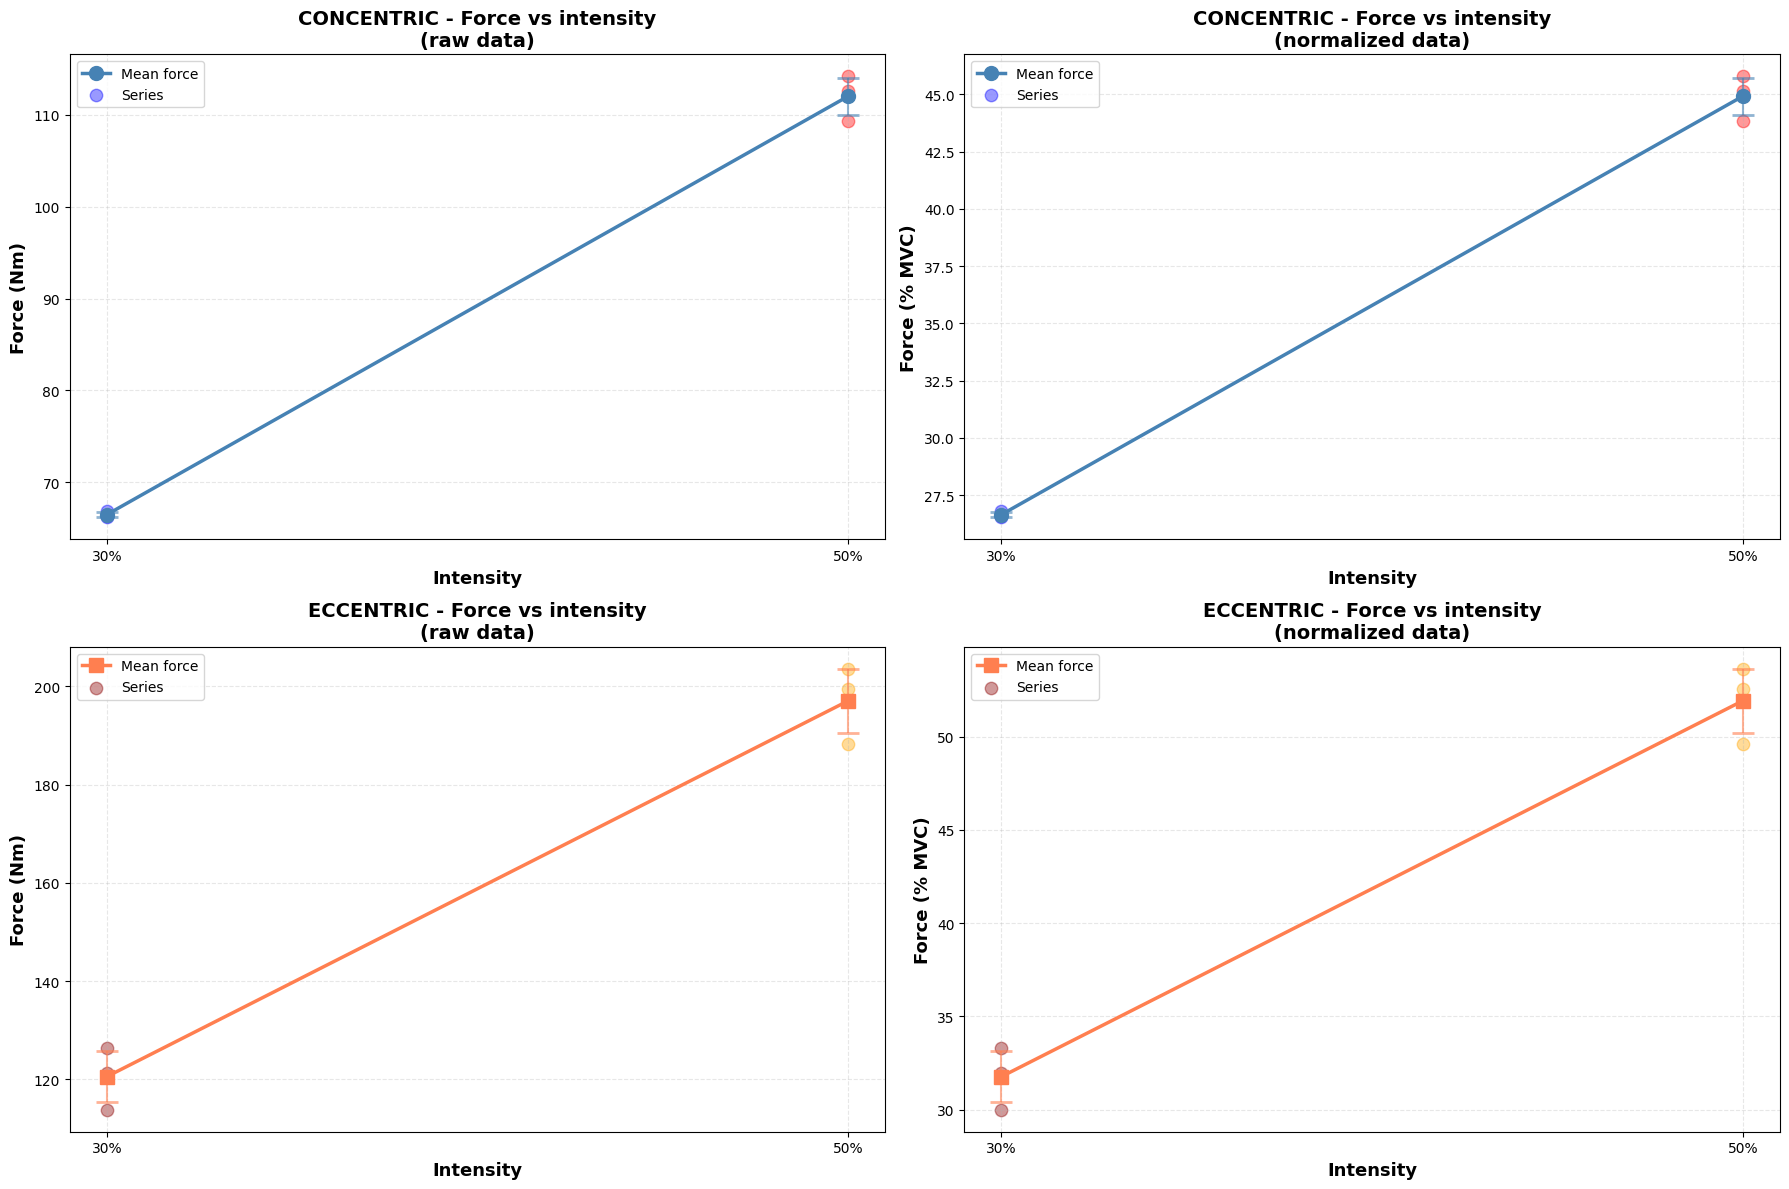

In [153]:
# Compare torque between two intensities for concentric and eccentric tasks
window = 30
peak_min_interval = 2.6

comparison = TORQUE_oxymove.compare_subject_torque_modes(
    subject_id=subID,
    base_root=BASE_ROOT,
    concentric_session='001',
    eccentric_session='002',
    window=window,
    peak_min_interval=peak_min_interval,
    make_plot=True,
    )

# Inject legacy variable names for downstream notebook cells
globals().update(TORQUE_oxymove.unpack_comparison_legacy_variables(comparison))

## Group mean across all subjects (Con30/Con50/Ecc30/Ecc50)


PROCESSING CONCENTRIC DATA
Con30 set 1: 10 peaks detected, mean = 66.211 Nm
Con30 set 2: 10 peaks detected, mean = 66.321 Nm
Con30 set 3: 10 peaks detected, mean = 66.854 Nm
Con50 set 1: 10 peaks detected, mean = 112.592 Nm
Con50 set 2: 10 peaks detected, mean = 114.200 Nm
Con50 set 3: 10 peaks detected, mean = 109.352 Nm

PROCESSING ECCENTRIC DATA
Ecc30 set 1: 8 peaks detected, mean = 126.443 Nm
Ecc30 set 2: 10 peaks detected, mean = 121.374 Nm
Ecc30 set 3: 10 peaks detected, mean = 113.809 Nm
Ecc50 set 1: 10 peaks detected, mean = 203.505 Nm
Ecc50 set 2: 9 peaks detected, mean = 199.543 Nm
Ecc50 set 3: 10 peaks detected, mean = 188.196 Nm
Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
Best MVC among reference trials: 212.705 Nm
Acceptance range (+/- 15.0%): [180.800, 244.611] Nm
Last MVC: 249.429 Nm
MVC quality check FAILED. Subject should be excluded from analysis.
Max torque for each MVC: [320.0

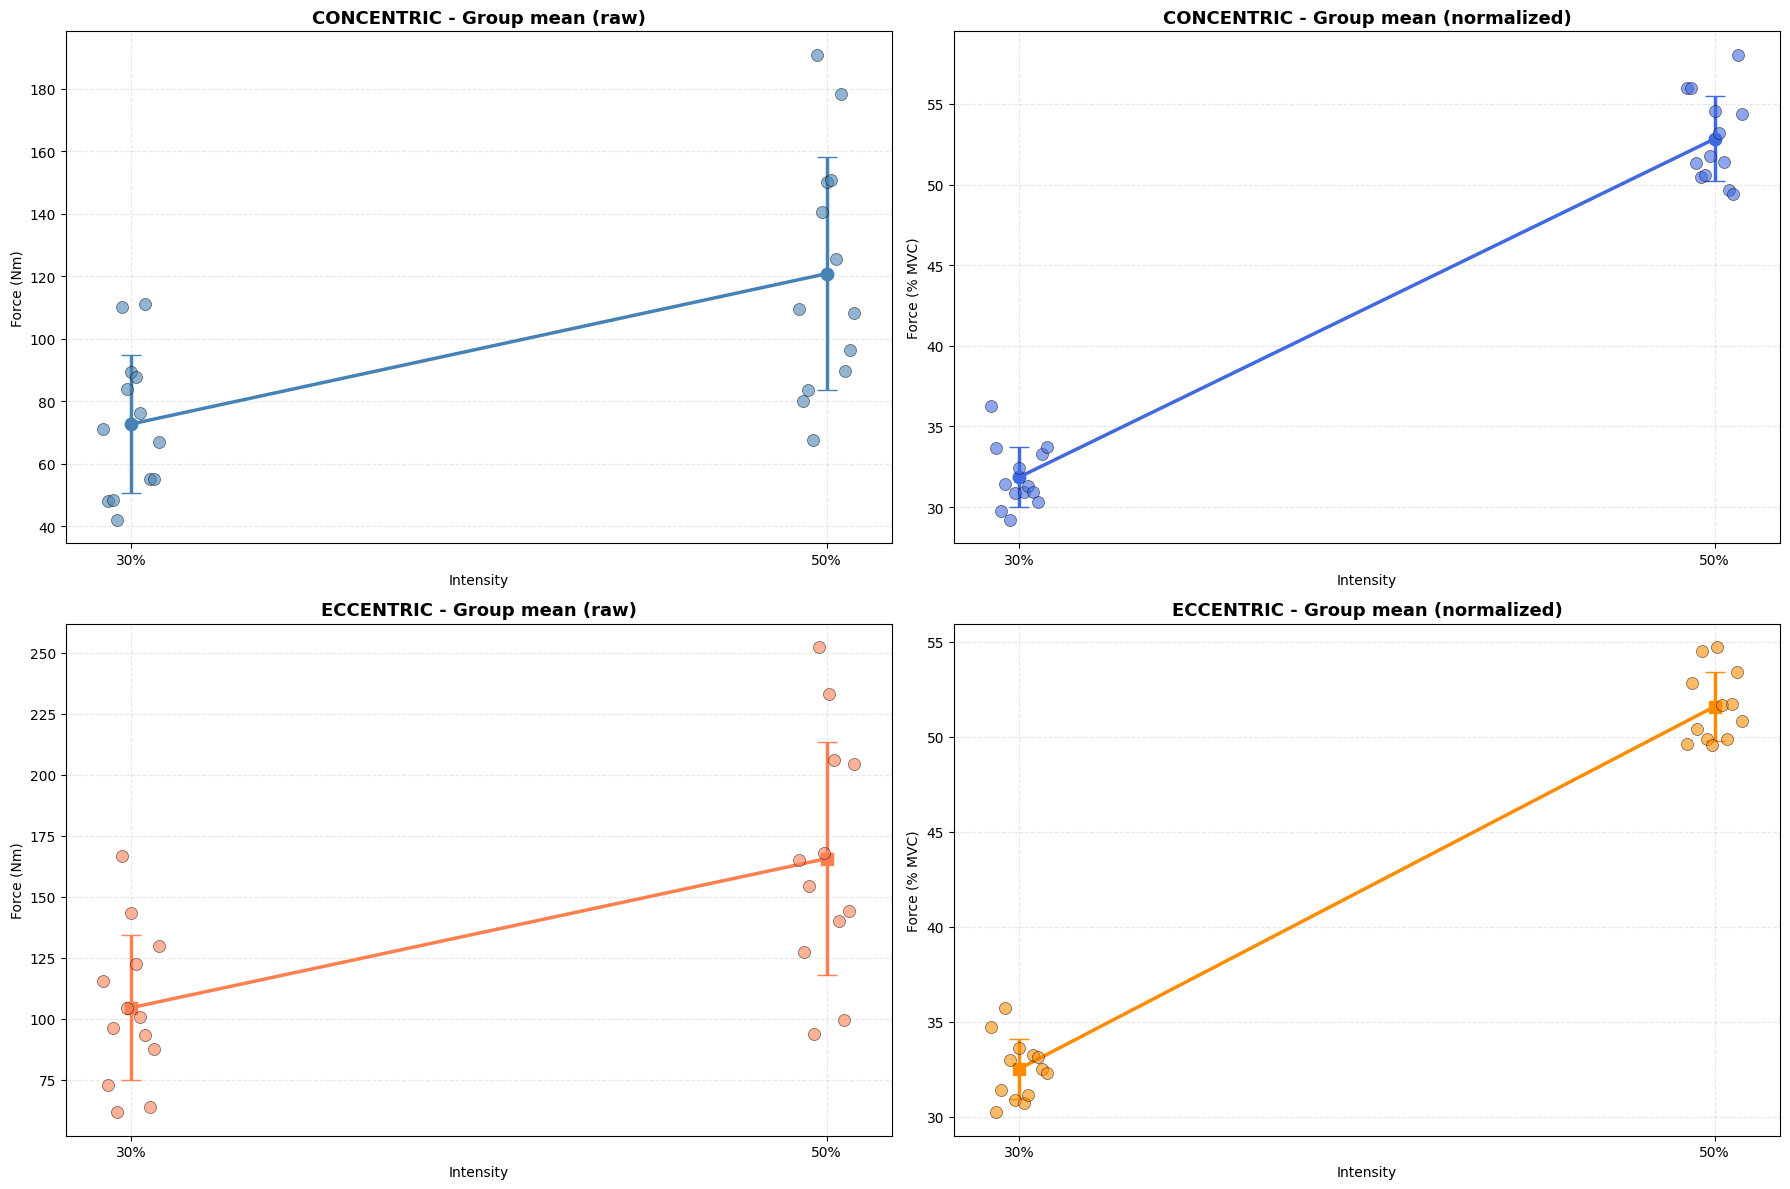

Subjects used: ['002', '003', '005', '006', '007', '009', '010', '012', '013', '015', '016', '018', '023']

GROUP TORQUE SUMMARY
Con30: 72.700 +/- 22.010 Nm (n=13), 31.86 +/- 1.88 %MVC (n=13)
Con50: 120.811 +/- 37.375 Nm (n=13), 52.84 +/- 2.64 %MVC (n=13)
Ecc30: 104.491 +/- 29.726 Nm (n=13), 32.52 +/- 1.57 %MVC (n=13)
Ecc50: 165.608 +/- 47.829 Nm (n=12), 51.58 +/- 1.80 %MVC (n=12)


{'Con30': {'mean_nm': 72.69978464814815,
  'std_nm': 22.009507200826924,
  'n_nm': 13,
  'mean_pct': 31.862108262296445,
  'std_pct': 1.8779238128758078,
  'n_pct': 13},
 'Con50': {'mean_nm': 120.81144022577054,
  'std_nm': 37.3748473499264,
  'n_nm': 13,
  'mean_pct': 52.83654051677506,
  'std_pct': 2.6391021959659233,
  'n_pct': 13},
 'Ecc30': {'mean_nm': 104.49077822408702,
  'std_nm': 29.725651850302583,
  'n_nm': 13,
  'mean_pct': 32.51719925446922,
  'std_pct': 1.5702957213603932,
  'n_pct': 13},
 'Ecc50': {'mean_nm': 165.6076839869809,
  'std_nm': 47.828516748040094,
  'n_nm': 12,
  'mean_pct': 51.5835711343644,
  'std_pct': 1.8004269955379308,
  'n_pct': 12}}

In [154]:
group_comparison = TORQUE_oxymove.compare_group_torque_modes(
    subject_ids=None,            # None = all subjects found in BASE_ROOT
    base_root=BASE_ROOT,
    concentric_session=None,     # auto-detect per subject
    eccentric_session=None,      # auto-detect per subject
    window=30,
    peak_min_interval=2.6,
    enforce_mvc_eligibility=True,
    mvc_window=6,
    mvc_tolerance_pct=0.15,
    make_plot=True,
    print_stats=True,
    )

group_summary = group_comparison['summary']
group_summary

## This cell helps to visualize the peak detection, if the set has been done correclty, we sould see 10 peaks for each set. 


PROCESSING CONCENTRIC DATA
Con30 set 1: 9 peaks detected, mean = 47.189 Nm
Con30 set 2: 9 peaks detected, mean = 49.610 Nm
Con30 set 3: 8 peaks detected, mean = 47.522 Nm
Con50 set 1: 10 peaks detected, mean = 83.285 Nm
Con50 set 2: 10 peaks detected, mean = 78.734 Nm
Con50 set 3: 9 peaks detected, mean = 77.778 Nm

PROCESSING ECCENTRIC DATA
Ecc30 set 1: 10 peaks detected, mean = 75.410 Nm
Ecc30 set 2: 10 peaks detected, mean = 70.883 Nm
Ecc30 set 3: 10 peaks detected, mean = 72.213 Nm
Ecc50 set 1: 8 peaks detected, mean = 135.735 Nm
Ecc50 set 2: 10 peaks detected, mean = 121.729 Nm
Ecc50 set 3: 9 peaks detected, mean = 124.231 Nm


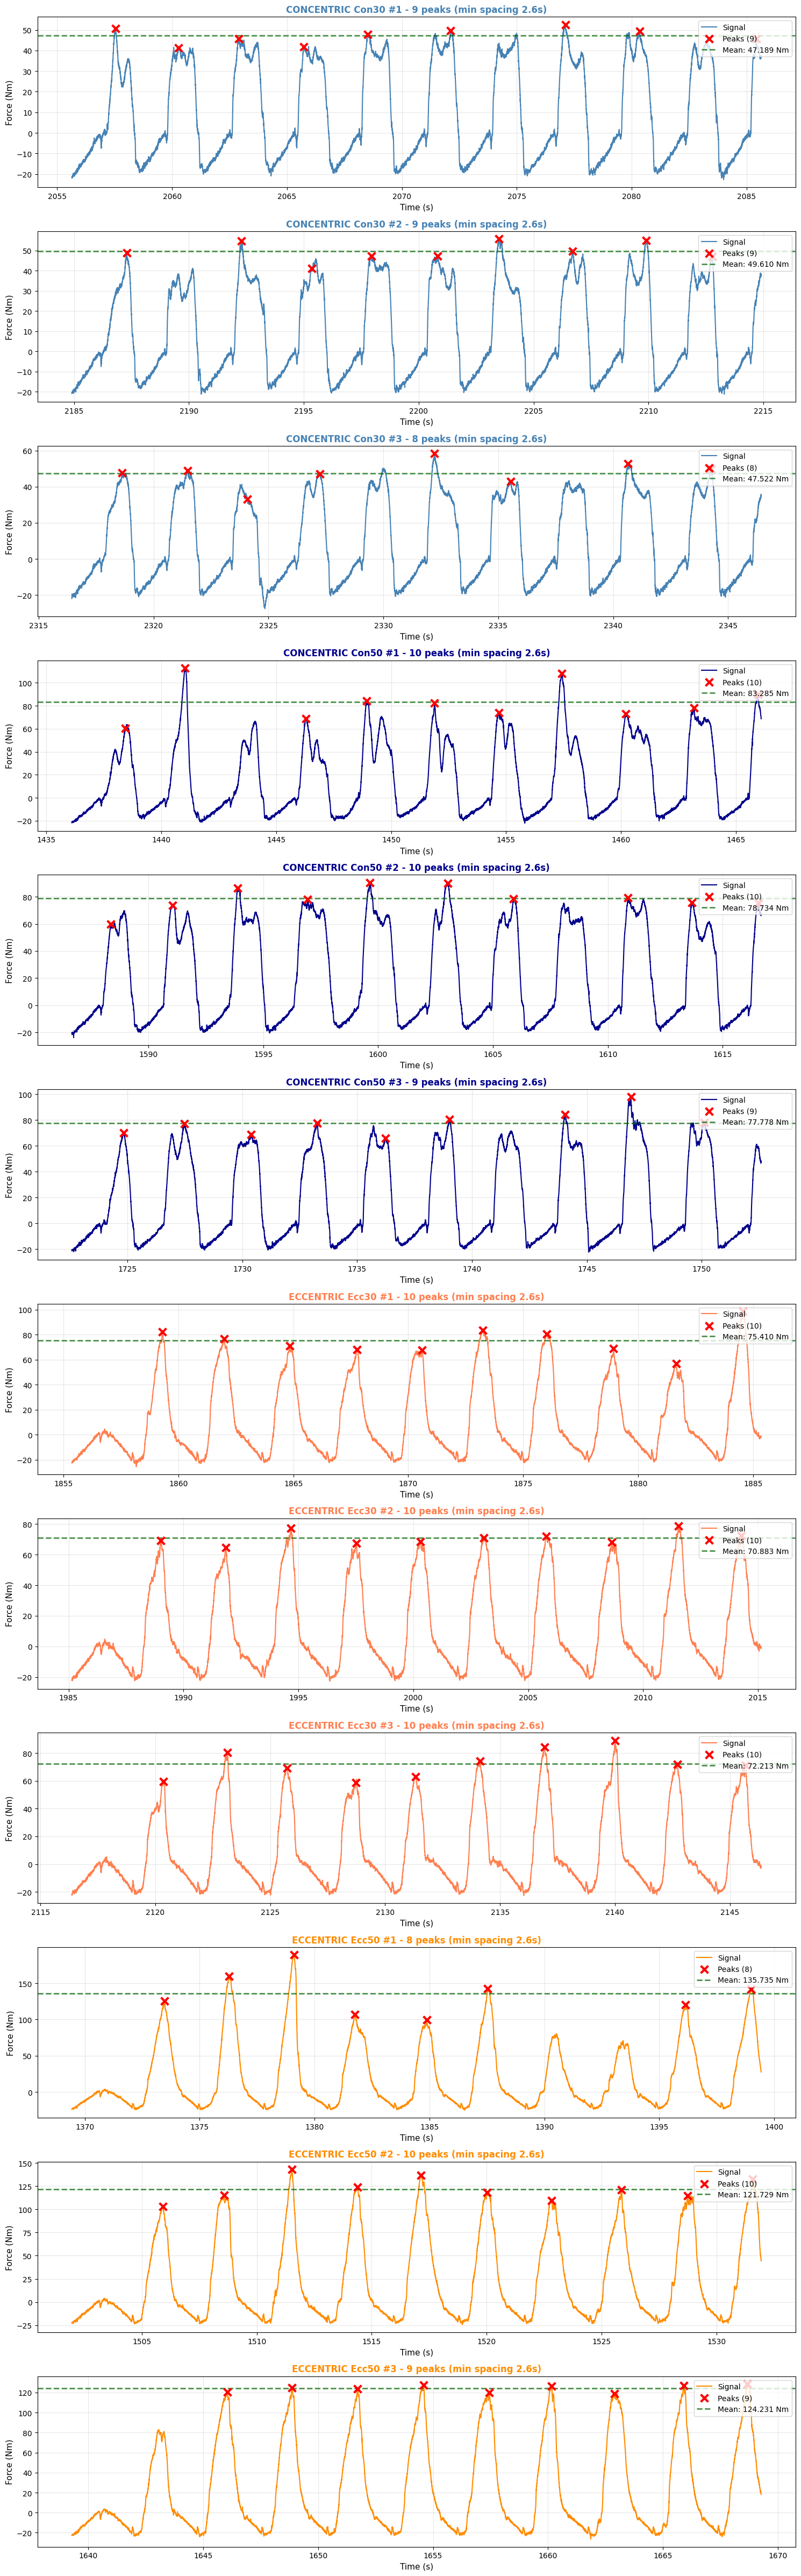

Displayed 12 set(s) for subject 003.


In [155]:
# Peak detection visualization for one chosen subject
peak_subject = '003' # ex: '001', '002', ...

peak_view = TORQUE_oxymove.plot_peak_detection_for_subject(
    subject_id=peak_subject,
    base_root=BASE_ROOT,
    concentric_session=None,   # auto-detect concentric session for this subject
    eccentric_session=None,    # auto-detect eccentric session for this subject
    window=30,
    peak_min_interval=2.6,
    figure_width=15,
    )

print(f"Displayed {peak_view['total_plots']} set(s) for subject {peak_subject}.")

## This cell do the 2 previous one for all subjects and sessions, and save the results in a csv file.


In [156]:
BASE_DIR = TORQUE_oxymove.DEFAULT_BASE_ROOT
OUTPUT_FILE = r"C:\Program Files\DigiMove\DigiMove\DataAnalysisProject\Analysis_Results\torque_analysis_results.csv"
TASK_MODES = {
    'concentric': {'Con30': 0.3, 'Con50': 0.5},
    'eccentric': {'Ecc30': 0.3, 'Ecc50': 0.5},
}

df_results = TORQUE_oxymove.export_torque_summary_csv(
    base_dir=BASE_DIR,
    output_file=OUTPUT_FILE,
    task_modes=TASK_MODES,
    window_contraction=30,
    peak_min_interval=2.6,
    enforce_mvc_eligibility=True,
    mvc_window=6,
    mvc_tolerance_pct=0.15,
    print_progress=True,
    )

print('\nSummary of results:')
print(df_results.to_string())


Processing sub-001 - ses-001 - concentric...
Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
Best MVC among reference trials: 212.705 Nm
Acceptance range (+/- 15.0%): [180.800, 244.611] Nm
Last MVC: 249.429 Nm
MVC quality check FAILED. Subject should be excluded from analysis.
  Skipped by MVC QC: last=249.43 Nm, range=[180.80, 244.61] Nm

Processing sub-001 - ses-002 - eccentric...
Max torque for each MVC: [320.09274, 379.47406, 356.336, 367.76102]
Average Max Torque across the 3 first MVCs: 351.9676 Nm
Best MVC among reference trials: 379.474 Nm
Acceptance range (+/- 15.0%): [322.553, 436.395] Nm
Last MVC: 367.761 Nm
MVC quality check PASSED. Subject can be used.
  Ecc30: Mean=128.97 Nm (34.0% MVC), n=3
  Ecc50: Mean=210.29 Nm (55.4% MVC), n=3

Processing sub-002 - ses-001 - eccentric...
Max torque for each MVC: [306.94196, 332.62427, 322.39456, 296.99307]
Average Max Torque across the 3 first MVCs